Players: 100
K-MEANS CLUSTERING (k = 2)
Silhouette Score: 0.343

Cluster Summary:
                     SR    AVG    RUNS  SIXES  Price_Cr
cluster_name                                           
High Performers  163.72  37.89  392.31  20.53     10.97
Low Performers   127.04  18.85  106.29   5.09      4.44

Cluster Counts:
cluster_name
Low Performers     55
High Performers    45
Name: count, dtype: int64


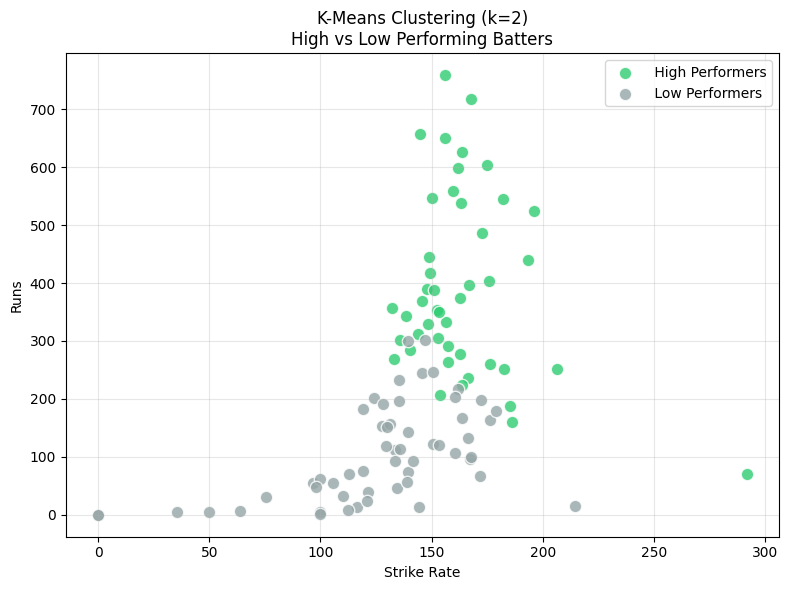

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

bat = pd.read_csv("cleaned_batters.csv")
ar  = pd.read_csv("cleaned_allrounders.csv")

all_bat = pd.concat([
    bat[['Player','Team','Abbr','Price_Cr','RUNS','AVG','SR','SIXES']],
    ar[['Player','Team','Abbr','Price_Cr','RUNS','Bat_AVG','Bat_SR','SIXES']]
        .rename(columns={'Bat_AVG':'AVG','Bat_SR':'SR'})
], ignore_index=True).dropna()

print(f"Players: {len(all_bat)}")
print("=" * 50)
print("K-MEANS CLUSTERING (k = 2)")
print("=" * 50)

features = ['SR','AVG','RUNS','SIXES','Price_Cr']
X = all_bat[features].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
all_bat['cluster'] = kmeans.fit_predict(X_scaled)

sil = silhouette_score(X_scaled, all_bat['cluster'])
print(f"Silhouette Score: {sil:.3f}")

cluster_runs = all_bat.groupby("cluster")["RUNS"].mean()

high_perf_cluster = cluster_runs.idxmax()
low_perf_cluster  = cluster_runs.idxmin()

all_bat["cluster_name"] = all_bat["cluster"].map({
    high_perf_cluster: " High Performers",
    low_perf_cluster: " Low Performers"
})

print("\nCluster Summary:")
print(all_bat.groupby("cluster_name")[features].mean().round(2))

print("\nCluster Counts:")
print(all_bat["cluster_name"].value_counts())

plt.figure(figsize=(8,6))

colors = {
    " High Performers": "#2ECC71",
    " Low Performers": "#95A5A6"
}

for name, grp in all_bat.groupby("cluster_name"):
    plt.scatter(
        grp["SR"], grp["RUNS"],
        color=colors[name],
        s=80, alpha=0.8,
        edgecolors="white",
        label=name
    )

plt.xlabel("Strike Rate")
plt.ylabel("Runs")
plt.title("K-Means Clustering (k=2)\nHigh vs Low Performing Batters")
plt.legend()

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

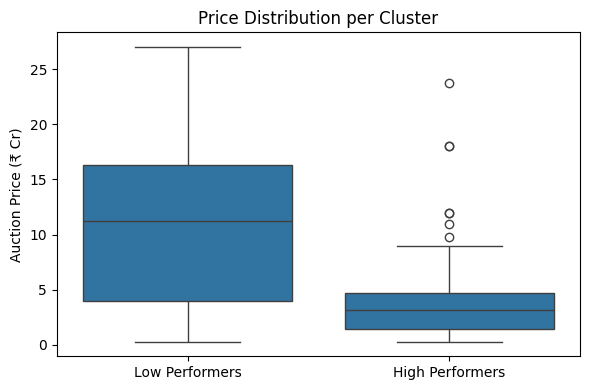

In [ ]:
plt.figure(figsize=(6,4))

cluster_names = {
    0: "High Performers",
    1: "Low Performers",
}

all_bat["cluster_name"] = all_bat["cluster"].map(cluster_names)

import seaborn as sns

sns.boxplot(
    data=all_bat,
    x="cluster_name",
    y="Price_Cr"
)

plt.xlabel("")
plt.ylabel("Auction Price (₹ Cr)")
plt.title("Price Distribution per Cluster")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ── Load data (mirror of Model.ipynb Cell 0) ──────────────────────────────
bowl = pd.read_csv("cleaned_bowlers.csv")
ar   = pd.read_csv("cleaned_allrounders.csv")

# Combine bowlers + all-rounder bowling stats
# All-rounders have Bowl_AVG, Bowl_ECON, Bowl_SR, WKTS columns
all_bowl = pd.concat([
    bowl[['Player', 'Team', 'Abbr', 'Price_Cr', 'WKTS', 'AVG', 'ECON', 'SR']],
    ar[['Player', 'Team', 'Abbr', 'Price_Cr', 'WKTS', 'Bowl_AVG', 'ECON', 'Bowl_SR']]
      .rename(columns={'Bowl_AVG': 'AVG', 'Bowl_ECON': 'ECON', 'Bowl_SR': 'SR'})
], ignore_index=True).dropna()

print(f"Bowlers + All-rounders: {len(all_bowl)}")
print(all_bowl[['WKTS', 'AVG', 'ECON', 'SR', 'Price_Cr']].describe().round(2))

Bowlers + All-rounders: 88
        WKTS     AVG   ECON     SR  Price_Cr
count  88.00   88.00  88.00  88.00     88.00
mean    8.22   40.86   9.83  24.25      6.04
std     6.37   27.32   1.53  13.65      5.41
min     1.00    6.50   6.50   5.00      0.30
25%     2.00   24.60   8.82  15.94      1.50
50%     6.50   32.50   9.63  21.14      4.00
75%    13.00   48.50  10.81  27.12     10.19
max    25.00  175.00  14.10  85.00     18.00


In [4]:
print("=" * 50)
print("K-MEANS CLUSTERING (k = 2) — BOWLERS")
print("=" * 50)

# ── Fit final model ───────────────────────────────────────────────────────
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
all_bowl['cluster'] = kmeans.fit_predict(X_scaled)

sil = silhouette_score(X_scaled, all_bowl['cluster'])
print(f"Silhouette Score: {sil:.3f}")

# ── Label clusters by average wickets (mirror of batter: label by avg RUNS)
cluster_wkts = all_bowl.groupby('cluster')['WKTS'].mean()
high_perf_cluster = cluster_wkts.idxmax()
low_perf_cluster  = cluster_wkts.idxmin()

all_bowl['cluster_name'] = all_bowl['cluster'].map({
    high_perf_cluster: ' High Performers',
    low_perf_cluster:  ' Low Performers'
})

print("\nCluster Summary:")
print(all_bowl.groupby('cluster_name')[features].mean().round(2))

print("\nCluster Counts:")
print(all_bowl['cluster_name'].value_counts())

K-MEANS CLUSTERING (k = 2) — BOWLERS
Silhouette Score: 0.322

Cluster Summary:
                  ECON    AVG   WKTS     SR  Price_Cr
cluster_name                                         
High Performers   9.22  27.62  10.97  18.03      7.18
Low Performers   11.07  67.79   2.62  36.89      3.72

Cluster Counts:
cluster_name
High Performers    59
Low Performers     29
Name: count, dtype: int64


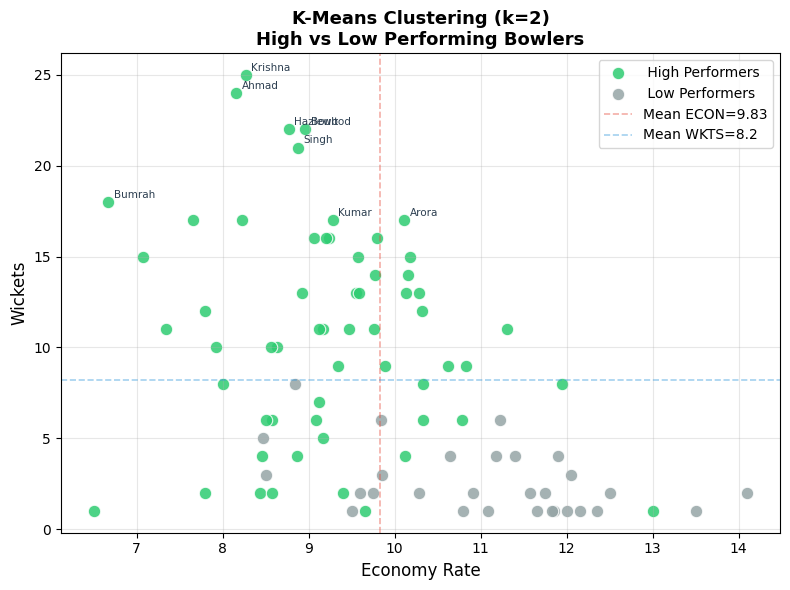

In [5]:
# ── Scatter: ECON vs WKTS — mirror of batter SR vs RUNS ──────────────────
plt.figure(figsize=(8, 6))

colors = {
    ' High Performers': '#2ECC71',
    ' Low Performers':  '#95A5A6'
}

for name, grp in all_bowl.groupby('cluster_name'):
    plt.scatter(
        grp['ECON'], grp['WKTS'],
        color=colors[name],
        s=80, alpha=0.85,
        edgecolors='white', linewidth=0.8,
        label=name
    )

# Annotate top 8 wicket-takers
top8 = all_bowl.nlargest(8, 'WKTS')
for _, row in top8.iterrows():
    short = row['Player'].split()[-1]
    plt.annotate(
        short,
        xy=(row['ECON'], row['WKTS']),
        xytext=(4, 3), textcoords='offset points',
        fontsize=7.5, color='#2C3E50'
    )

# Mean crosshair lines
plt.axvline(all_bowl['ECON'].mean(), linestyle='--', color='#E74C3C',
            alpha=0.45, linewidth=1.2, label=f'Mean ECON={all_bowl["ECON"].mean():.2f}')
plt.axhline(all_bowl['WKTS'].mean(), linestyle='--', color='#3498DB',
            alpha=0.45, linewidth=1.2, label=f'Mean WKTS={all_bowl["WKTS"].mean():.1f}')

plt.xlabel('Economy Rate', fontsize=12)
plt.ylabel('Wickets', fontsize=12)
plt.title('K-Means Clustering (k=2)\nHigh vs Low Performing Bowlers', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('bowl_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\saket\AppData\Local\Temp\ipykernel_14712\1934093692.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


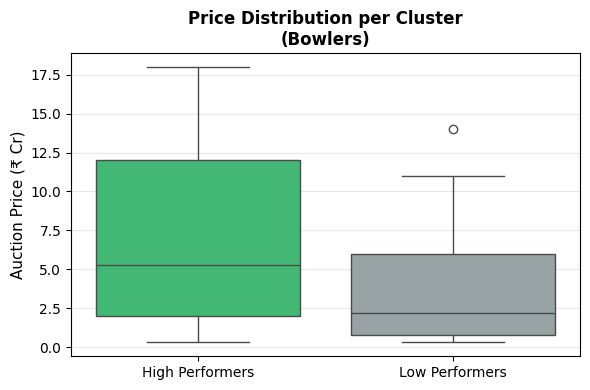

In [6]:
# ── Boxplot: Price per cluster — exact mirror of Model.ipynb Cell 1 ───────
plt.figure(figsize=(6, 4))

# Map names to clean labels (drop leading space)
all_bowl['cluster_label'] = all_bowl['cluster_name'].str.strip()

sns.boxplot(
    data=all_bowl,
    x='cluster_label',
    y='Price_Cr',
    palette={'High Performers': '#2ECC71', 'Low Performers': '#95A5A6'}
)

plt.xlabel('')
plt.ylabel('Auction Price (₹ Cr)', fontsize=11)
plt.title('Price Distribution per Cluster\n(Bowlers)', fontsize=12, fontweight='bold')
plt.xticks(rotation=0)
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('bowl_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

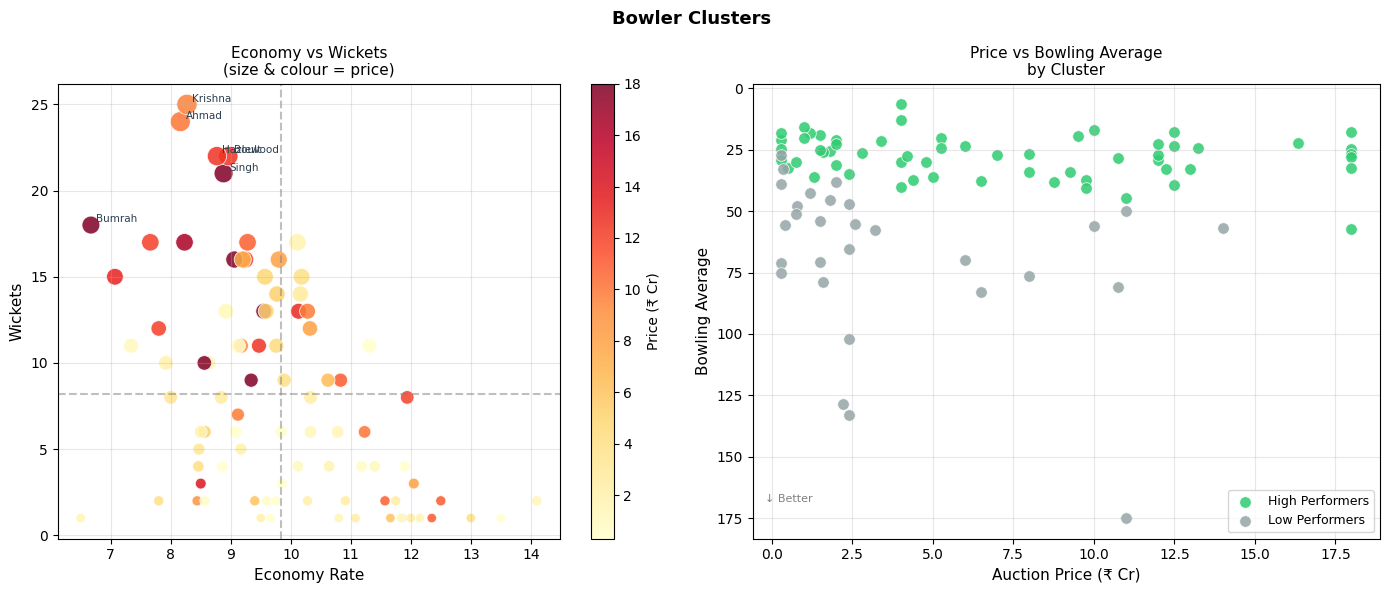


FINAL CLUSTER SUMMARY — BOWLERS
                 Count  Avg_WKTS  Avg_ECON  Avg_AVG  Avg_SR  Avg_Price
cluster_label                                                         
High Performers     59     10.97      9.22    27.62   18.03       7.18
Low Performers      29      2.62     11.07    67.79   36.89       3.72

Top 5 High Performers:
         Player                        Team  WKTS  ECON   AVG  Price_Cr
Prasidh Krishna              Gujarat Titans  25.0  8.27 19.52       9.5
     Noor Ahmad         Chennai Super Kings  24.0  8.16 17.00      10.0
    Trent Boult              Mumbai Indians  22.0  8.96 23.50      12.5
 Josh Hazlewood Royal Challengers Bengaluru  22.0  8.77 17.54      12.5
 Arshdeep Singh                Punjab Kings  21.0  8.88 24.66      18.0

Top 5 Low Performers (by wickets):
       Player                        Team  WKTS  ECON  AVG  Price_Cr
Anrich Nortje       Kolkata Knight Riders   1.0 11.85 83.0       6.5
 Rasikh Salam Royal Challengers Bengaluru   1.0 11.66

In [8]:
# ── Enhanced scatter: colour = Price, shape = cluster ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Bowler Clusters ', fontsize=13, fontweight='bold')

# --- Left: Price as colour ---
sc = axes[0].scatter(
    all_bowl['ECON'], all_bowl['WKTS'],
    c=all_bowl['Price_Cr'], cmap='YlOrRd',
    s=all_bowl['WKTS'] * 7 + 40,
    alpha=0.85, edgecolors='white', linewidth=0.6
)
plt.colorbar(sc, ax=axes[0], label='Price (₹ Cr)')

# Annotate top 6
for _, row in all_bowl.nlargest(6, 'WKTS').iterrows():
    axes[0].annotate(row['Player'].split()[-1],
                     xy=(row['ECON'], row['WKTS']),
                     xytext=(4, 2), textcoords='offset points',
                     fontsize=7.5, color='#2C3E50')

axes[0].axvline(all_bowl['ECON'].mean(), linestyle='--', color='gray', alpha=0.5)
axes[0].axhline(all_bowl['WKTS'].mean(), linestyle='--', color='gray', alpha=0.5)
axes[0].set_xlabel('Economy Rate', fontsize=11)
axes[0].set_ylabel('Wickets', fontsize=11)
axes[0].set_title('Economy vs Wickets\n(size & colour = price)', fontsize=11)
axes[0].grid(alpha=0.3)

# --- Right: Avg vs Price coloured by cluster ---
c_map = {' High Performers': '#2ECC71', ' Low Performers': '#95A5A6'}
for name, grp in all_bowl.groupby('cluster_name'):
    axes[1].scatter(
        grp['Price_Cr'], grp['AVG'],
        color=c_map[name], s=70, alpha=0.85,
        edgecolors='white', linewidth=0.6,
        label=name.strip()
    )

axes[1].set_xlabel('Auction Price (₹ Cr)', fontsize=11)
axes[1].set_ylabel('Bowling Average', fontsize=11)
axes[1].set_title('Price vs Bowling Average\nby Cluster', fontsize=11)
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)
axes[1].invert_yaxis()  # lower avg = better for bowlers
axes[1].annotate('↓ Better', xy=(0.02, 0.08), xycoords='axes fraction',
                 fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('bowl_extra.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Final summary ─────────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("FINAL CLUSTER SUMMARY — BOWLERS")
print("=" * 55)
summary = all_bowl.groupby('cluster_label').agg(
    Count      = ('Player', 'count'),
    Avg_WKTS   = ('WKTS', 'mean'),
    Avg_ECON   = ('ECON', 'mean'),
    Avg_AVG    = ('AVG', 'mean'),
    Avg_SR     = ('SR', 'mean'),
    Avg_Price  = ('Price_Cr', 'mean')
).round(2)
print(summary.to_string())

print("\nTop 5 High Performers:")
hp = all_bowl[all_bowl['cluster_label'] == 'High Performers'].nlargest(5, 'WKTS')
print(hp[['Player', 'Team', 'WKTS', 'ECON', 'AVG', 'Price_Cr']].to_string(index=False))

print("\nTop 5 Low Performers (by wickets):")
lp = all_bowl[all_bowl['cluster_label'] == 'Low Performers'].nsmallest(5, 'WKTS')
print(lp[['Player', 'Team', 'WKTS', 'ECON', 'AVG', 'Price_Cr']].to_string(index=False))